# Language Models for Text Classification 

## 0. Setup

In [2]:
import os
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from groq import Groq
from mistralai.client import Mistral
from collections import Counter

In [3]:
%env GROQ_API_KEY=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
%env MISTRAL_API_KEY=pojygBcty1joDr7csFHKQIJTVFHQCRTX

env: GROQ_API_KEY=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
env: MISTRAL_API_KEY=pojygBcty1joDr7csFHKQIJTVFHQCRTX


In [4]:
LABELS = [
    "Anthropic",
    "Google",
    "Human",
    "Meta",
    "OpenAI"
]

SIZE = 50

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")

print(f"Groq key loaded: {GROQ_API_KEY is not None}")
print(f"Mistral key loaded: {MISTRAL_API_KEY is not None}")

#Groq Models
GROQ_MODEL1 = "llama-3.1-8b-instant"
GROQ_MODEL2 = "llama-3.3-70b-versatile"

#Mistral Models
MISTRAL_MODEL1 = "mistral-large-latest"
MISTRAL_MODEL2 = "mistral-medium"
MISTRAL_MODEL3 = "mistral-large"

groq_client = Groq(api_key='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')
mistral_client = Mistral(api_key='pojygBcty1joDr7csFHKQIJTVFHQCRTX')

Groq key loaded: True
Mistral key loaded: True


## 1. Carregamento e Pré-processamento dos Dados

In [18]:
df_train = pd.read_csv("data/train.csv", sep=";")
df_test = pd.read_csv("data/test.csv", sep=";")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.strip()

df_train["clean_text"] = df_train["Text"].apply(clean_text)
df_test["clean_text"] = df_test["Text"].apply(clean_text)
df_test = df_test[:50]

gold_test = df_test["Label"].tolist()

In [ ]:
len(df_test)

50

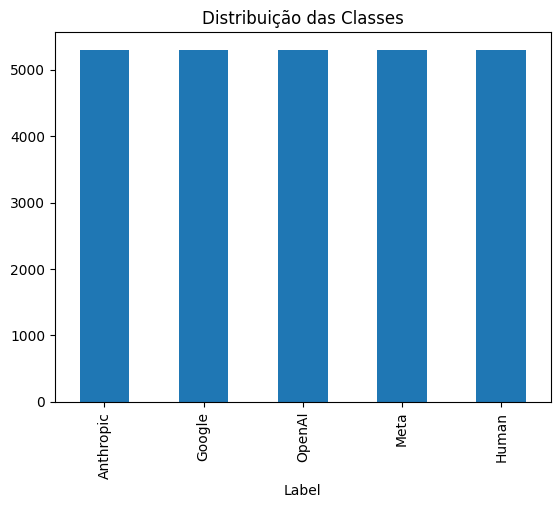

In [ ]:
df_train["Label"].value_counts().plot(kind="bar", title="Distribuição das Classes")
plt.show()

## 2. Build prompts

Definição do *prompt* para classificar textos.

zero-shot vs few-shot

In [8]:
def build_zero_shot_prompt(example):
    prompt = f"""
You are a strict classifier.

Possible labels:
Anthropic, Google, Human, Meta, OpenAI

Return ONLY one label.

Text:\n
{example["clean_text"]}
"""
    return prompt.strip()

In [9]:
support_examples = df_train.sample(n=5).to_dict(orient="records")

def format_example(ex):
    return f"""
Text: "{ex["clean_text"]}"
Label: {ex["Label"]}
"""

def build_few_shot_prompt(example, support_examples):
    support_block = ""

    for support_example in support_examples:
        support_block += format_example(support_example)
    
    prompt = f"""
You are a text classifier.

Possible labels:
Anthropic, Google, Human, Meta, OpenAI

Examples:
{support_block}

Now classify:

Text:
{example["clean_text"]}

Return ONE and ONLY label.
"""
    return prompt.strip()

## 3. API helpers

In [19]:
def ask_groq(prompt, model=GROQ_MODEL1):
    response = groq_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    
    print(response)

    return response.choices[0].message.content

In [20]:
def ask_mistral(prompt, model=MISTRAL_MODEL1):
    response = mistral_client.chat.complete(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    
    print(response)

    return response.choices[0].message.content

In [21]:
VALID_LABELS = set(LABELS)

def normalize_prediction(text):
    if text is None:
        return None

    text = text.strip()

    if text in VALID_LABELS:
        return text

    for label in VALID_LABELS:
        if label.lower() in text.lower():
            return label
            
    return None

In [22]:
def evaluate_predictions(predictions, gold_labels):
    rows = []
    for gold_label, prediction in zip(gold_labels, predictions):
        rows.append({
            "gold_label": gold_label,
            "prediction": prediction,
            "correct":    prediction == gold_label,
        })
    return pd.DataFrame(rows)

In [23]:
def accuracy(preds, gold_labels):
    if not gold_labels:
        return 0.0
    return sum(p == g for p, g in zip(preds, gold_labels)) / len(gold_labels)



## 4. Zero-shot classification

In [24]:
def run_experiment(
    dataset_split,
    ask_fn,
    model_name,
    prompt_builder,
    support_examples=None,
    sleep_seconds=0.8,
):

    predictions, raw_outputs = [], []

    for example in dataset_split:
        try:
            prompt = (
                prompt_builder(example, support_examples)
                if support_examples
                else prompt_builder(example)
            )
            raw  = ask_fn(prompt, model=model_name)
            pred = normalize_prediction(raw)
            raw_outputs.append(raw)
            predictions.append(pred)
        except Exception as e:
            print(f"Error: {e}")
            raw_outputs.append(None)
            predictions.append(None)

        time.sleep(sleep_seconds)

    return predictions, raw_outputs

In [25]:
zs_groq_preds1, zs_groq_raw1 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL1,
    prompt_builder=build_zero_shot_prompt,
)

ChatCompletion(id='chatcmpl-814eed3e-f1c1-41a0-933c-974091886c04', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774969097, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_03e8423237', usage=CompletionUsage(completion_tokens=3, prompt_tokens=182, total_tokens=185, completion_time=0.007702492, completion_tokens_details=None, prompt_time=0.012755213, prompt_tokens_details=None, queue_time=0.018789528, total_time=0.020457705), usage_breakdown=None, x_groq=XGroq(id='req_01kn26e3epej3be0bv2c7r1j2n', debug=None, seed=711029157, usage=None))
ChatCompletion(id='chatcmpl-06316313-c78f-40e4-bc46-27911308235f', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', a

In [26]:
print(accuracy(zs_groq_preds1, gold_test))
Counter(zs_groq_preds1)

0.36


Counter({'Human': 24, 'Anthropic': 19, 'OpenAI': 5, 'Meta': 2})

In [27]:
zs_groq_preds2, zs_groq_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL2,
    prompt_builder=build_zero_shot_prompt,
    sleep_seconds=2
)

ChatCompletion(id='chatcmpl-02ee1ee6-6232-4b1a-93a0-57c713c1ed17', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774969186, model='llama-3.3-70b-versatile', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_43d97c5965', usage=CompletionUsage(completion_tokens=2, prompt_tokens=182, total_tokens=184, completion_time=0.015029857, completion_tokens_details=None, prompt_time=0.128670446, prompt_tokens_details=None, queue_time=0.526199645, total_time=0.143700303), usage_breakdown=None, x_groq=XGroq(id='req_01kn26gsfnf1pt0k0gtm6bwbmz', debug=None, seed=638060676, usage=None))
ChatCompletion(id='chatcmpl-c637311b-72dd-45e5-b24a-ea8b34971ba1', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant',

In [29]:
groq_eval1 = evaluate_predictions(zs_groq_preds1, gold_test)
groq_eval2 = evaluate_predictions(zs_groq_preds2, gold_test)

print("Groq:")
display(groq_eval1)
display(groq_eval2)

Groq:


,gold_label,prediction,correct
0,Human,OpenAI,False
1,Meta,Human,False
2,Google,Human,False
3,Meta,Anthropic,False
4,Human,Human,True
5,Google,Human,False
6,OpenAI,Human,False
7,Meta,Human,False
8,Google,OpenAI,False
9,Human,Anthropic,False


,gold_label,prediction,correct
0,Human,Human,True
1,Meta,Human,False
2,Google,Human,False
3,Meta,OpenAI,False
4,Human,Human,True
5,Google,OpenAI,False
6,OpenAI,OpenAI,True
7,Meta,Human,False
8,Google,OpenAI,False
9,Human,OpenAI,False


In [30]:
zs_mistral_preds1, zs_mistral_raw1 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL1,
    prompt_builder=build_zero_shot_prompt,
    sleep_seconds=2
)

id='ef8941e836604595bf9b1d7fd557d60e' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=150, completion_tokens=2, total_tokens=152, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774969307 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='cc7d5590912446708eed368768b71262' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=152, completion_tokens=2, total_tokens=154, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774969309 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='e055a52840a442f99cba9b91515570b7' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=180, completion_tokens=2, total_tokens=182, prompt_a

In [31]:
print(accuracy(zs_mistral_preds1, gold_test))
Counter(zs_mistral_preds1)


0.4


Counter({'Human': 50})

In [32]:
zs_mistral_preds2, zs_mistral_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL2,
    prompt_builder=build_zero_shot_prompt,
    sleep_seconds=2,
)

id='3e8ca155fff7494a880fc81fa29f8288' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=150, completion_tokens=2, total_tokens=152, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774969492 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='3bff81a9996840bc8dfc300b73579343' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=152, completion_tokens=2, total_tokens=154, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774969496 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='9e8aff93c95e4a4a83514e154bd6db92' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=180, completion_tokens=2, total_tokens=182, prompt_audio_seconds=Unset

In [33]:
print(accuracy(zs_mistral_preds2, gold_test))
Counter(zs_mistral_preds2)

0.4


Counter({'Human': 49, None: 1})

In [34]:
mistral_eval1 = evaluate_predictions(zs_mistral_preds1, gold_test)
mistral_eval2 = evaluate_predictions(zs_mistral_preds2, gold_test)

print("Mistral:")
display(mistral_eval1)
display(mistral_eval2)

Mistral:


,gold_label,prediction,correct
0,Human,Human,True
1,Meta,Human,False
2,Google,Human,False
3,Meta,Human,False
4,Human,Human,True
5,Google,Human,False
6,OpenAI,Human,False
7,Meta,Human,False
8,Google,Human,False
9,Human,Human,True


,gold_label,prediction,correct
0,Human,Human,True
1,Meta,Human,False
2,Google,Human,False
3,Meta,Human,False
4,Human,Human,True
5,Google,Human,False
6,OpenAI,Human,False
7,Meta,Human,False
8,Google,Human,False
9,Human,Human,True


## 5. Few-shot classification

In few-shot prompting, we include a small number of labeled examples in the prompt.

In [37]:
support_examples = []
support_examples1 = []
seen = set()
seen1 = set()
complete = False

for _, row in df_train.iterrows():
    label = row["Label"]
    
    if label not in seen:
        support_examples.append(row.to_dict())
        seen.add(label)
        continue
    
    if label not in seen1:
        support_examples1.append(row.to_dict())
        seen1.add(label)
    
    if len(seen) == len(LABELS) and len(seen1) == len(LABELS):
        break


for ex in support_examples:
    print(ex["Label"])
    print(format_example(ex))
    print("-" * 80)
            
for ex in support_examples1:
    print(ex["Label"])
    print(format_example(ex))
    print("-" * 80)

print(f"Support set size: {len(support_examples)} — Support set size1: {len(support_examples1)} - labels: {seen}\n")
    

Anthropic

Text: "the human heart beats approximately         times per day"
Label: Anthropic

--------------------------------------------------------------------------------
Google

Text: "the human brain is a complex organ  consuming approximately     of the body s total oxygen and calories"
Label: Google

--------------------------------------------------------------------------------
OpenAI

Text: "water is a polar molecule  resulting in unique properties like high surface tension and the ability to dissolve many substances"
Label: OpenAI

--------------------------------------------------------------------------------
Meta

Text: "the human nose can detect over   trillion different scents due to hundreds of different types of olfactory receptors"
Label: Meta

--------------------------------------------------------------------------------
Human

Text: "the cell is the basic structural and functional unit of all forms of life or organisms"
Label: Human

---------------------------

In [38]:
gold_test = df_test["Label"].tolist()

fs_groq_preds1, fs_groq_raw = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL1,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

ChatCompletion(id='chatcmpl-e15ebba5-c001-4053-851c-811ae3729252', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774969854, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_6a1eabf260', usage=CompletionUsage(completion_tokens=2, prompt_tokens=317, total_tokens=319, completion_time=0.008435501, completion_tokens_details=None, prompt_time=0.021154559, prompt_tokens_details=None, queue_time=0.019247698, total_time=0.02959006), usage_breakdown=None, x_groq=XGroq(id='req_01kn275658e7g8ga4v5ha5230r', debug=None, seed=1245054592, usage=None))
ChatCompletion(id='chatcmpl-e3aefa5f-659f-40da-8464-dfbf82b8447f', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', an

In [54]:
print(accuracy(fs_groq_preds1, gold_test))
Counter(fs_groq_preds1)

0.4


Counter({'Human': 50})

In [40]:
fs_groq_preds11, fs_groq_raw = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL1,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples1,
)

ChatCompletion(id='chatcmpl-36ecfa7a-ff8e-47eb-b957-bee01f45e2e3', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Anthropic', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774969962, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_8639719ff2', usage=CompletionUsage(completion_tokens=3, prompt_tokens=327, total_tokens=330, completion_time=0.008973185, completion_tokens_details=None, prompt_time=0.025908402, prompt_tokens_details=None, queue_time=0.01937959, total_time=0.034881587), usage_breakdown=None, x_groq=XGroq(id='req_01kn278fvpene8e8c689zakqzb', debug=None, seed=1901046656, usage=None))
ChatCompletion(id='chatcmpl-d86a5879-b5ca-4f1f-bf0f-00dbb9c0f933', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant'

In [41]:
print(accuracy(fs_groq_preds11, gold_test))
Counter(fs_groq_preds11)

0.3


Counter({'Anthropic': 28, 'Human': 22})

In [42]:

fs_groq_preds2, fs_groq_raw = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL2,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

ChatCompletion(id='chatcmpl-94b57462-6954-41b7-b26c-98d377e6a2d8', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774970130, model='llama-3.3-70b-versatile', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_68f543a7cc', usage=CompletionUsage(completion_tokens=3, prompt_tokens=317, total_tokens=320, completion_time=0.015916698, completion_tokens_details=None, prompt_time=0.076615698, prompt_tokens_details=None, queue_time=0.1093885, total_time=0.092532396), usage_breakdown=None, x_groq=XGroq(id='req_01kn27dkg0e5rrmf9687njrhvz', debug=None, seed=203616416, usage=None))
ChatCompletion(id='chatcmpl-be01c837-b106-404c-b34d-5fa9c83a9c2e', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant',

In [43]:
print(accuracy(fs_groq_preds2, gold_test))
Counter(fs_groq_preds2)

0.12


Counter({'OpenAI': 45, 'Anthropic': 3, 'Human': 2})

In [44]:

fs_groq_preds22, fs_groq_raw = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL2,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples1,
)

ChatCompletion(id='chatcmpl-7123a46b-bad8-4bbb-bb8c-5021fcab7e85', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774970232, model='llama-3.3-70b-versatile', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_f8b414701e', usage=CompletionUsage(completion_tokens=3, prompt_tokens=327, total_tokens=330, completion_time=0.014925498, completion_tokens_details=None, prompt_time=0.073897134, prompt_tokens_details=None, queue_time=0.076741988, total_time=0.088822632), usage_breakdown=None, x_groq=XGroq(id='req_01kn27gqjfewwsqcvv6hrj6k4f', debug=None, seed=1054676812, usage=None))
ChatCompletion(id='chatcmpl-99c1f1a2-acae-4912-8a89-4fbe723fb498', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistan

In [45]:
print(accuracy(fs_groq_preds22, gold_test))
Counter(fs_groq_preds22)

0.2


Counter({'OpenAI': 33, 'Anthropic': 12, 'Human': 5})

In [46]:
df_fs_groq1    = evaluate_predictions(fs_groq_preds1,    gold_test)
df_fs_groq11    = evaluate_predictions(fs_groq_preds11,    gold_test)
df_fs_groq2    = evaluate_predictions(fs_groq_preds2,    gold_test)
df_fs_groq22    = evaluate_predictions(fs_groq_preds22,    gold_test)

print("=== Groq few-shot ===")
display(df_fs_groq1)
display(df_fs_groq2)

=== Groq few-shot ===


,gold_label,prediction,correct
0,Human,Human,True
1,Meta,Human,False
2,Google,Human,False
3,Meta,Human,False
4,Human,Human,True
5,Google,Human,False
6,OpenAI,Human,False
7,Meta,Human,False
8,Google,Human,False
9,Human,Human,True


,gold_label,prediction,correct
0,Human,OpenAI,False
1,Meta,OpenAI,False
2,Google,OpenAI,False
3,Meta,OpenAI,False
4,Human,Anthropic,False
5,Google,OpenAI,False
6,OpenAI,OpenAI,True
7,Meta,OpenAI,False
8,Google,OpenAI,False
9,Human,OpenAI,False


In [62]:
fs_mistral_preds1, _ = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL1,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

id='14ec059ecd15492d92c481a12c158888' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=284, completion_tokens=2, total_tokens=286, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774978879 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='02036b1d1256468391c797e70059c3ee' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=286, completion_tokens=2, total_tokens=288, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774978881 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='52ee643a050c4b9a8070729de6578dff' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=314, completion_tokens=2, total_tokens=316, prompt_a

In [63]:
print(accuracy(fs_mistral_preds1, gold_test))
Counter(fs_mistral_preds1)


0.34


Counter({'Human': 42, 'OpenAI': 4, 'Meta': 4})

In [64]:
fs_mistral_preds11, fs_mistral_raw1 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL1,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples1,
)

id='785a57d63a2d44deaac9c803ca104cce' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=289, completion_tokens=2, total_tokens=291, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774978992 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='ffba0995110f4a169a441b9d5f2f5eb9' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=291, completion_tokens=2, total_tokens=293, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774978993 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='8a1f3d98411c4fe6a5b5af771f75ae21' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=319, completion_tokens=3, total_tokens=322, prompt_a

In [65]:
print(accuracy(fs_mistral_preds11, gold_test))
Counter(fs_mistral_preds11)

0.34


Counter({'Human': 35, 'OpenAI': 9, 'Meta': 4, 'Anthropic': 2})

In [84]:

fs_mistral_preds2, fs_mistral_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL2,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

id='5cffb63e556a4f848fb4af53338db015' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=284, completion_tokens=2, total_tokens=286, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774979883 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Meta', tool_calls=None, prefix=False), finish_reason='stop')]
id='d3e5c0abce2b4c989bb964d6471e01bb' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=286, completion_tokens=2, total_tokens=288, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774979884 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Meta', tool_calls=None, prefix=False), finish_reason='stop')]
id='ef939cf046594ba3a9835a914a0abcab' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=314, completion_tokens=2, total_tokens=316, prompt_audio_seconds=Unset()

In [85]:
print(accuracy(fs_mistral_preds2, gold_test))
Counter(fs_mistral_preds2)

0.1


Counter({'Meta': 23, None: 23, 'OpenAI': 3, 'Human': 1})

In [76]:
fs_mistral_preds22, fs_mistral_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL2,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples1,
)

id='6fc6d91b03554a41b3db0a5ba16d41e7' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=289, completion_tokens=2, total_tokens=291, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774979438 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Meta', tool_calls=None, prefix=False), finish_reason='stop')]
id='ba9eaa2d42f3427883c63ad5dce3ec14' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=291, completion_tokens=2, total_tokens=293, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774979439 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Meta', tool_calls=None, prefix=False), finish_reason='stop')]
id='81838398871a488195543753c716ab61' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=319, completion_tokens=2, total_tokens=321, prompt_audio_seconds=Unset()

In [77]:
print(accuracy(fs_mistral_preds22, gold_test))
Counter(fs_mistral_preds22)

0.1


Counter({None: 25, 'Meta': 23, 'Anthropic': 1, 'Human': 1})

In [82]:
df_fs_mistral1 = evaluate_predictions(fs_mistral_preds1, gold_test)
df_fs_mistral11 = evaluate_predictions(fs_mistral_preds11, gold_test)
df_fs_mistral2 = evaluate_predictions(fs_mistral_preds2, gold_test)
df_fs_mistral22 = evaluate_predictions(fs_mistral_preds22, gold_test)


#print("\n=== Mistral few-shot ===")
#display(df_fs_mistral1)
#display(df_fs_mistral2)

## 6. Comparação e Análise de Resultados



,Model,Accuracy
0,llama-3.1-8b-instant zero-shot,0.36
1,llama-3.1-8b-instant few-shot,0.40
2,llama-3.3-70b-versatile zero-shot,0.36
3,llama-3.3-70b-versatile few-shot,0.12
4,mistral-large-latest zero-shot,0.40
5,mistral-large-latest few-shot,0.34


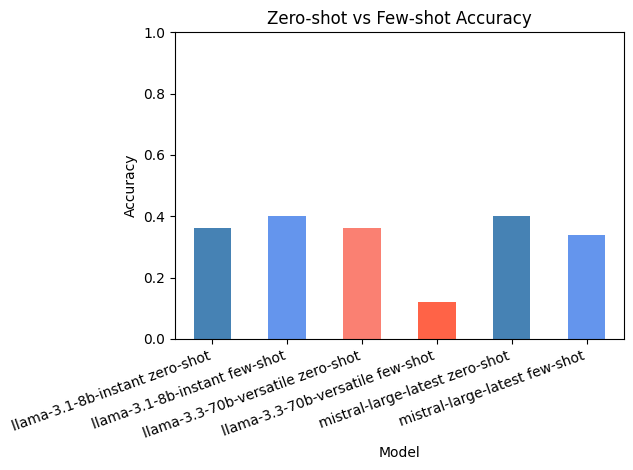

In [86]:
results = {
    "llama-3.1-8b-instant zero-shot":    accuracy(zs_groq_preds1,    gold_test),
    "llama-3.1-8b-instant few-shot":     accuracy(fs_groq_preds1,    gold_test),
    
    "llama-3.3-70b-versatile zero-shot":    accuracy(zs_groq_preds2,    gold_test),
    "llama-3.3-70b-versatile few-shot":     accuracy(fs_groq_preds2,    gold_test),
    
    "mistral-large-latest zero-shot": accuracy(zs_mistral_preds1,  gold_test),
    "mistral-large-latest few-shot":  accuracy(fs_mistral_preds1,  gold_test),

    #"mistral-medium zero-shot": accuracy(zs_mistral_preds2,  gold_test),
    #"mistral-medium few-shot":  accuracy(fs_mistral_preds2,  gold_test),
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
display(results_df)

results_df.set_index("Model")["Accuracy"].plot(
    kind="bar",
    title="Zero-shot vs Few-shot Accuracy",
    ylim=(0, 1),
    color=["steelblue", "cornflowerblue", "salmon", "tomato"],
)
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

,Model,Accuracy
0,llama-3.1-8b-instant few-shot 1,0.40
1,llama-3.1-8b-instant few-shot 2,0.30
2,llama-3.3-70b-versatile few-shot 1,0.12
3,llama-3.3-70b-versatile few-shot 2,0.20
4,mistral-large-latest few-shot 1,0.34
5,mistral-large-latest few-shot 2,0.34


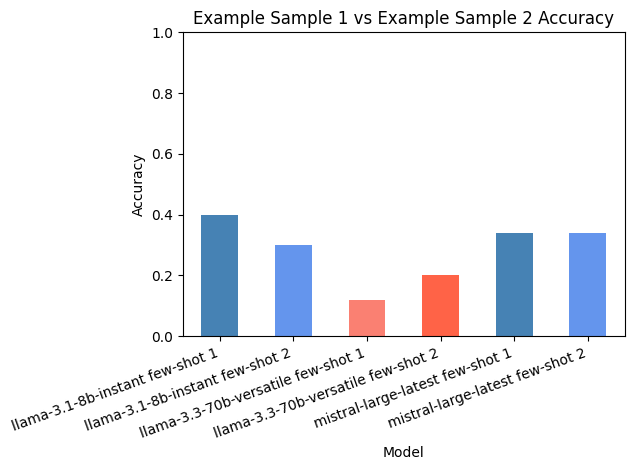

In [87]:
results = {
    "llama-3.1-8b-instant few-shot 1":     accuracy(fs_groq_preds1,    gold_test),
    "llama-3.1-8b-instant few-shot 2":     accuracy(fs_groq_preds11,    gold_test),
    
    "llama-3.3-70b-versatile few-shot 1":     accuracy(fs_groq_preds2,    gold_test),
    "llama-3.3-70b-versatile few-shot 2":     accuracy(fs_groq_preds22,    gold_test),
    
    "mistral-large-latest few-shot 1":  accuracy(fs_mistral_preds1,  gold_test),
    "mistral-large-latest few-shot 2":  accuracy(fs_mistral_preds11,  gold_test),

    #"mistral-medium few-shot 1":  accuracy(fs_mistral_preds2,  gold_test),
    #"mistral-medium few-shot 2":  accuracy(fs_mistral_preds22,  gold_test),
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
display(results_df)

results_df.set_index("Model")["Accuracy"].plot(
    kind="bar",
    title="Example Sample 1 vs Example Sample 2 Accuracy",
    ylim=(0, 1),
    color=["steelblue", "cornflowerblue", "salmon", "tomato"],
)
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [72]:
print(accuracy(zs_groq_preds1, gold_test))
print(Counter(zs_groq_preds1))
print(accuracy(zs_groq_preds2, gold_test))
print(Counter(zs_groq_preds2))

print(accuracy(zs_mistral_preds1, gold_test))
print(Counter(zs_mistral_preds1))
print(accuracy(zs_mistral_preds2, gold_test))
print(Counter(zs_mistral_preds2))


0.36
Counter({'Human': 24, 'Anthropic': 19, 'OpenAI': 5, 'Meta': 2})
0.36
Counter({'OpenAI': 29, 'Human': 21})
0.4
Counter({'Human': 50})
0.4
Counter({'Human': 49, None: 1})


In [73]:
print(accuracy(fs_groq_preds1, gold_test))
print(Counter(fs_groq_preds1))
print(accuracy(fs_groq_preds11, gold_test))
print(Counter(fs_groq_preds11))

print(accuracy(fs_groq_preds2, gold_test))
print(Counter(fs_groq_preds2))
print(accuracy(fs_groq_preds22, gold_test))
print(Counter(fs_groq_preds22))

0.4
Counter({'Human': 50})
0.3
Counter({'Anthropic': 28, 'Human': 22})
0.12
Counter({'OpenAI': 45, 'Anthropic': 3, 'Human': 2})
0.2
Counter({'OpenAI': 33, 'Anthropic': 12, 'Human': 5})


In [88]:

print(accuracy(fs_mistral_preds1, gold_test))
print(Counter(fs_mistral_preds1))
print(accuracy(fs_mistral_preds11, gold_test))
print(Counter(fs_mistral_preds11))
# print(accuracy(fs_mistral_preds2, gold_test))
# print(Counter(fs_mistral_preds2))
# print(accuracy(fs_mistral_preds22, gold_test))
# print(Counter(fs_mistral_preds22))


0.34
Counter({'Human': 42, 'OpenAI': 4, 'Meta': 4})
0.34
Counter({'Human': 35, 'OpenAI': 9, 'Meta': 4, 'Anthropic': 2})
